In [1]:
import pandas as pd
import skimage
from skimage.feature import graycomatrix, graycoprops
from skimage import io
from imblearn.over_sampling import SMOTE, ADASYN
from shutil import copyfile
from skimage.filters import gabor
import sys
from PIL import Image
from sklearn.model_selection import train_test_split
from numpy import load
from ast import Global
import tensorflow as tf, re, math
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models
from tensorflow import keras
from keras.applications import ResNet50, InceptionV3, EfficientNetB7
from tensorflow.keras import layers
from keras.models import Sequential, Model
from keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D, GlobalAveragePooling2D
from keras.optimizers import Adam, Nadam, Adamax
from keras.metrics import categorical_crossentropy
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from ast import Global
import keras.backend as K
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adamax
import itertools
import os
import shutil
import random
import glob
import warnings
import zipfile
warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline

In [41]:
o_data_path = r'C:\Dat\Research\Folder\Final\PhotoAgruFinal'  
o_test_path = r'C:\Dat\Research\Final\PhotoTrain\test' 


In [42]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)
batch_size = 10
img_size = (224, 224)

In [43]:
def create_dataframe(data_path):
    filepaths = []
    labels = []

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):  # Chỉ lấy ảnh
                full_path = os.path.join(root, file)  # Đường dẫn đầy đủ

                filepaths.append(full_path)
                labels.append(os.path.basename(root))  # Nhãn là tên thư mục cha

    dataframe = pd.DataFrame({'filepath': filepaths, 'label': labels})
    return dataframe


**VGG16**

In [44]:
dataframe = create_dataframe(o_data_path)

datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input)

test_batches = datagen.flow_from_directory(
    directory=o_test_path,
    target_size=img_size,
    classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
    batch_size=batch_size,
    shuffle=False
)

Found 21990 images belonging to 5 classes.


In [6]:
#bth
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adamax
import numpy as np
import matplotlib.pyplot as plt

def fourier_transform_layer(inputs):
    gray_image = tf.image.rgb_to_grayscale(inputs)  
    gray_image = tf.squeeze(gray_image, axis=-1) 

    F1 = tf.signal.fft2d(tf.cast(gray_image, tf.complex64)) 
    F2 = tf.signal.fftshift(F1) 

    magnitude_spectrum = tf.math.log(1.0 + tf.abs(F2))

    magnitude_spectrum = tf.expand_dims(magnitude_spectrum, axis=-1)

    return magnitude_spectrum

def build_model1():
    vgg16_model = tf.keras.applications.VGG16(include_top=False, input_shape=(224, 224, 3))
    vgg16_model.trainable = False  # Đóng băng toàn bộ mô hình

    inputs = layers.Input(shape=(224, 224, 3))

    fft_layer = layers.Lambda(fourier_transform_layer)(inputs)

    high_pass_filter = np.array([[-1, 2, -2, 2, -1],
                                 [2, -6, 8, -6, 2],
                                 [-2, 8, -12, 8, -2],
                                 [2, -6, 8, -6, 2],
                                 [-1, 2, -2, 2, -1]], dtype=np.float32)
    high_pass_filter = high_pass_filter.reshape((5, 5, 1, 1))  # Định dạng kernel cho Conv2D

    x1 = layers.Conv2D(filters=1, kernel_size=(5, 5), padding='same',
                       kernel_initializer=tf.constant_initializer(high_pass_filter))(fft_layer)

    x1 = tf.image.grayscale_to_rgb(x1)

    x1 = vgg16_model(x1)
    x2 = vgg16_model(inputs)

    x1 = layers.GlobalAveragePooling2D()(x1)
    x2 = layers.GlobalAveragePooling2D()(x2)

    merged = layers.concatenate([x1, x2])

    x = layers.Dense(units=1024, activation='relu')(merged)
    x = layers.Dense(units=1024, activation='relu')(x)
    x = layers.Dense(units=512, activation='relu')(x)
    outputs = layers.Dense(units=5, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adamax(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_model1()
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda (Lambda)                (None, 224, 224, 1)  0           ['input_2[0][0]']                
                                                                                                  
 conv2d (Conv2D)                (None, 224, 224, 1)  26          ['lambda[0][0]']                 
                                                                                                  
 tf.image.grayscale_to_rgb (TFO  (None, 224, 224, 3)  0          ['conv2d[0][0]']             

In [10]:
from keras_flops import get_flops

model1 = build_model1()

flops = get_flops(model1, batch_size=10)
print(f"FLOPs: {flops:,}")



FLOPs: 614,341,217,581


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adamax
import numpy as np
import matplotlib.pyplot as plt

def fourier_transform_layer(inputs):
    gray_image = tf.image.rgb_to_grayscale(inputs)  
    gray_image = tf.squeeze(gray_image, axis=-1)  

    F1 = tf.signal.fft2d(tf.cast(gray_image, tf.complex64)) 
    F2 = tf.signal.fftshift(F1)  

    magnitude_spectrum = tf.math.log(1.0 + tf.abs(F2))

    magnitude_spectrum = tf.expand_dims(magnitude_spectrum, axis=-1)

    return magnitude_spectrum

def build_model1():
    vgg16_model = tf.keras.applications.VGG16(include_top=False, input_shape=(224, 224, 3))
    vgg16_model.trainable = False  
    
    inputs = layers.Input(shape=(224, 224, 3))

    fft_layer = layers.Lambda(fourier_transform_layer)(inputs)

    high_pass_filter = np.array([[-1, 2, -2, 2, -1],
                                 [2, -6, 8, -6, 2],
                                 [-2, 8, -12, 8, -2],
                                 [2, -6, 8, -6, 2],
                                 [-1, 2, -2, 2, -1]], dtype=np.float32)
    high_pass_filter = high_pass_filter.reshape((5, 5, 1, 1))  # Định dạng kernel cho Conv2D

    x1 = layers.Conv2D(filters=1, kernel_size=(5, 5), padding='same',
                       kernel_initializer=tf.constant_initializer(high_pass_filter))(fft_layer)

    x1 = tf.image.grayscale_to_rgb(x1)

    x2 = layers.Conv2D(filters=3, kernel_size=(5, 5), activation='relu', padding='same')(inputs)    

    print("Shape of x1:", x1.shape)
    print("Shape of x2:", x2.shape)

    merged = layers.Concatenate(axis=-1)([x1, x2])
    
    x = layers.GlobalAveragePooling2D()(merged)

    x = vgg16_model(merged)
    x = layers.Dense(units=1024, activation='relu')(x)
    x = layers.Dense(units=1024, activation='relu')(x)
    x = layers.Dense(units=512, activation='relu')(x)
    outputs = layers.Dense(units=5, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adamax(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_model1()
model.summary()


In [21]:
os.makedirs('./models6/ckpt_vgg16/', exist_ok=True)

In [7]:
import tensorflow as tf
tf.keras.backend.clear_session()


In [8]:
fold = 1
for train_index, valid_index in kfold.split(dataframe):
    print(f"Training fold {fold}")
    
    df_train = dataframe.iloc[train_index]
    df_valid = dataframe.iloc[valid_index]
    
    train_batches = datagen.flow_from_dataframe(
        dataframe=df_train,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
        batch_size=batch_size
    )
    
    valid_batches = datagen.flow_from_dataframe(
        dataframe=df_valid,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
        batch_size=batch_size
    )
    
    model1 = build_model1()
    
    checkpoint_callback = ModelCheckpoint(
        filepath=f'./models6/ckpt_vgg16/fold_{fold}_checkpoint_{{epoch}}.model.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=2, 
        verbose=1,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,     
        patience=2,      
        min_lr=1e-6,     
        verbose=1
    )
    
    model1.fit(
        x=train_batches,
        validation_data=valid_batches,
        epochs=30,
        verbose=2,
        callbacks=[checkpoint_callback, early_stopping, reduce_lr]
    )
    
    fold += 1

Training fold 1
Found 23520 validated image filenames belonging to 5 classes.
Found 11760 validated image filenames belonging to 5 classes.
Epoch 1/5

Epoch 1: val_accuracy improved from -inf to 0.88699, saving model to ./models6/ckpt_vgg16\fold_1_checkpoint_1.model.keras
2352/2352 - 973s - loss: 0.4579 - accuracy: 0.8184 - val_loss: 0.2980 - val_accuracy: 0.8870 - lr: 1.0000e-04 - 973s/epoch - 414ms/step
Epoch 2/5

Epoch 2: val_accuracy improved from 0.88699 to 0.93376, saving model to ./models6/ckpt_vgg16\fold_1_checkpoint_2.model.keras
2352/2352 - 791s - loss: 0.1932 - accuracy: 0.9327 - val_loss: 0.1817 - val_accuracy: 0.9338 - lr: 1.0000e-04 - 791s/epoch - 336ms/step
Epoch 3/5

Epoch 3: val_accuracy improved from 0.93376 to 0.96412, saving model to ./models6/ckpt_vgg16\fold_1_checkpoint_3.model.keras
2352/2352 - 781s - loss: 0.1139 - accuracy: 0.9650 - val_loss: 0.1076 - val_accuracy: 0.9641 - lr: 1.0000e-04 - 781s/epoch - 332ms/step
Epoch 4/5

Epoch 4: val_accuracy improved from 

KeyboardInterrupt: 

In [38]:
import tensorflow as tf
import skimage
import sklearn
from tensorflow import keras
from tensorflow.keras.models import load_model
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import os
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

model_1 = load_model(r'./models3/ckpt_vgg16/fold_1_checkpoint_5.model.keras')

2199/2199 [==============================] - 329s 150ms/step
Accuracy: 0.9848
Confusion matrix, without normalization
[[4334    0    0    0   64]
 [   0 4354   23   21    0]
 [   0   28 4320   50    0]
 [   0   51   52 4291    4]
 [  41    0    1    0 4356]]


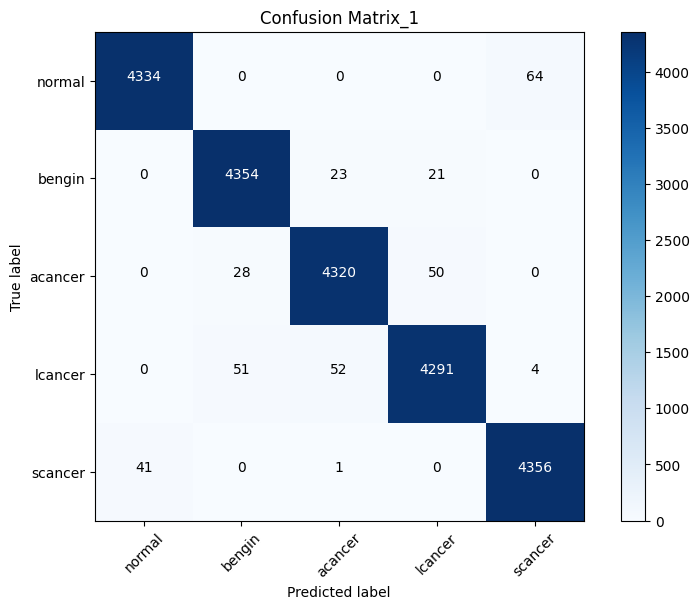

In [45]:
#Study 1

import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import itertools
import cv2
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import load_model

predictions = model_1.predict(x=test_batches, verbose=1)
y_true = test_batches.classes
y_pred = np.argmax(predictions, axis=-1)

accuracy = accuracy_score(y_true, y_pred)
print(f'Accuracy: {accuracy:.4f}')  # In độ chính xác với 4 chữ số thập phân

labels = [0, 1, 2, 3, 4]
cm = confusion_matrix(y_true=y_true, y_pred=y_pred, labels=labels)

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, f'{cm[i, j]}',
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

cm_plot_labels = ['normal', 'bengin', 'acancer', 'lcancer', 'scancer']
plot_confusion_matrix(cm=cm, classes=cm_plot_labels, title='Confusion Matrix_1')


**ResNet50**

In [11]:
dataframe = create_dataframe(o_data_path)

datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

test_batches = datagen.flow_from_directory(
    directory=o_test_path,
    target_size=img_size,
    classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
    batch_size=batch_size,
    shuffle=False
)

Found 21990 images belonging to 5 classes.


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adamax
import numpy as np
import matplotlib.pyplot as plt

def fourier_transform_layer(inputs):
    gray_image = tf.image.rgb_to_grayscale(inputs)  
    gray_image = tf.squeeze(gray_image, axis=-1)  
    F1 = tf.signal.fft2d(tf.cast(gray_image, tf.complex64))  
    F2 = tf.signal.fftshift(F1)  

    magnitude_spectrum = tf.math.log(1.0 + tf.abs(F2))

    magnitude_spectrum = tf.expand_dims(magnitude_spectrum, axis=-1)

    return magnitude_spectrum

def build_model2():
    resnet_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    resnet_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))

    fft_layer = layers.Lambda(fourier_transform_layer)(inputs)

    high_pass_filter = np.array([[-1, 2, -2, 2, -1],
                                 [2, -6, 8, -6, 2],
                                 [-2, 8, -12, 8, -2],
                                 [2, -6, 8, -6, 2],
                                 [-1, 2, -2, 2, -1]], dtype=np.float32)
    high_pass_filter = high_pass_filter.reshape((5, 5, 1, 1))  

    x1 = layers.Conv2D(filters=1, kernel_size=(5, 5), padding='same',
                       kernel_initializer=tf.constant_initializer(high_pass_filter))(fft_layer)

    x1 = tf.image.grayscale_to_rgb(x1)

    x1 = resnet_model(x1)
    x2 = resnet_model(inputs)

    x1 = layers.GlobalAveragePooling2D()(x1)
    x2 = layers.GlobalAveragePooling2D()(x2)

    merged = layers.concatenate([x1, x2])

    x = layers.Dense(units=1024, activation='relu')(merged)
    x = layers.Dense(units=1024, activation='relu')(x)
    x = layers.Dense(units=512, activation='relu')(x)
    outputs = layers.Dense(units=5, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Nadam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_model2()
model.summary()


Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda_4 (Lambda)              (None, 224, 224, 1)  0           ['input_10[0][0]']               
                                                                                                  
 conv2d_4 (Conv2D)              (None, 224, 224, 1)  26          ['lambda_4[0][0]']               
                                                                                                  
 tf.image.grayscale_to_rgb_4 (T  (None, 224, 224, 3)  0          ['conv2d_4[0][0]']         

In [13]:
from keras_flops import get_flops

model2 = build_model2()

flops = get_flops(model2, batch_size=10)
print(f"FLOPs: {flops:,}")



FLOPs: 155,166,102,061


In [ ]:
os.makedirs('./models3/ckpt_ResNet50/', exist_ok=True)

In [ ]:
fold = 1
for train_index, valid_index in kfold.split(dataframe):
    print(f"Training fold {fold}")
    
    df_train = dataframe.iloc[train_index]
    df_valid = dataframe.iloc[valid_index]
    
    train_batches = datagen.flow_from_dataframe(
        dataframe=df_train,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
        batch_size=batch_size
    )
    
    valid_batches = datagen.flow_from_dataframe(
        dataframe=df_valid,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
        batch_size=batch_size
    )
    
    model2 = build_model2()
    
    checkpoint_callback = ModelCheckpoint(
        filepath=f'./models3/ckpt_ResNet50/fold_{fold}_checkpoint_{{epoch}}.model.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=10,  
        verbose=1,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,      
        patience=5,      
        min_lr=1e-6,     
        verbose=1
    )
    
    model2.fit(
        x=train_batches,
        validation_data=valid_batches,
        epochs=5,
        verbose=2,
        callbacks=[checkpoint_callback, early_stopping, reduce_lr]
    )
    
    fold += 1

Training fold 1
Found 34200 validated image filenames belonging to 5 classes.
Found 17100 validated image filenames belonging to 5 classes.
Epoch 1/5

Epoch 1: val_accuracy improved from -inf to 0.92480, saving model to ./models3/ckpt_ResNet50\fold_1_checkpoint_1.model.keras
3420/3420 - 778s - loss: 0.4578 - accuracy: 0.8009 - val_loss: 0.1974 - val_accuracy: 0.9248 - lr: 1.0000e-04 - 778s/epoch - 227ms/step
Epoch 2/5

Epoch 2: val_accuracy improved from 0.92480 to 0.93883, saving model to ./models3/ckpt_ResNet50\fold_1_checkpoint_2.model.keras
3420/3420 - 707s - loss: 0.1792 - accuracy: 0.9311 - val_loss: 0.1575 - val_accuracy: 0.9388 - lr: 1.0000e-04 - 707s/epoch - 207ms/step
Epoch 3/5

Epoch 3: val_accuracy improved from 0.93883 to 0.96813, saving model to ./models3/ckpt_ResNet50\fold_1_checkpoint_3.model.keras
3420/3420 - 706s - loss: 0.1185 - accuracy: 0.9557 - val_loss: 0.0881 - val_accuracy: 0.9681 - lr: 1.0000e-04 - 706s/epoch - 206ms/step
Epoch 4/5

Epoch 4: val_accuracy impro

**Inception V3**

In [ ]:
dataframe = create_dataframe(o_data_path)

datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.inception_v3.preprocess_input)

test_batches = datagen.flow_from_directory(
    directory=o_test_path,
    target_size=img_size,
    classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
    batch_size=batch_size,
    shuffle=False
)

Found 21990 images belonging to 5 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adamax
import numpy as np
import matplotlib.pyplot as plt

def fourier_transform_layer(inputs):
    gray_image = tf.image.rgb_to_grayscale(inputs)  # Chuyển ảnh RGB sang Grayscale
    gray_image = tf.squeeze(gray_image, axis=-1)  # Loại bỏ kênh cuối để có (224, 224)

    F1 = tf.signal.fft2d(tf.cast(gray_image, tf.complex64))  # Biến đổi Fourier
    F2 = tf.signal.fftshift(F1)  # Dịch tâm tần số

    magnitude_spectrum = tf.math.log(1.0 + tf.abs(F2))

    magnitude_spectrum = tf.expand_dims(magnitude_spectrum, axis=-1)

    return magnitude_spectrum

def build_model3():
    inception_v3_model = InceptionV3(
            include_top=False,       # Bỏ lớp fully connected mặc định
            weights="imagenet",      # Tải trọng số pre-trained
            input_shape=(224, 224, 3)  # Kích thước input
        )
    inception_v3_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))

    fft_layer = layers.Lambda(fourier_transform_layer)(inputs)

    high_pass_filter = np.array([[-1, 2, -2, 2, -1],
                                 [2, -6, 8, -6, 2],
                                 [-2, 8, -12, 8, -2],
                                 [2, -6, 8, -6, 2],
                                 [-1, 2, -2, 2, -1]], dtype=np.float32)
    high_pass_filter = high_pass_filter.reshape((5, 5, 1, 1))  # Định dạng kernel cho Conv2D

    x1 = layers.Conv2D(filters=1, kernel_size=(5, 5), padding='same',
                       kernel_initializer=tf.constant_initializer(high_pass_filter))(fft_layer)

    x1 = tf.image.grayscale_to_rgb(x1)

    x1 = inception_v3_model(x1)
    x2 = inception_v3_model(inputs)

    x1 = layers.GlobalAveragePooling2D()(x1)
    x2 = layers.GlobalAveragePooling2D()(x2)

    merged = layers.concatenate([x1, x2])

    x = layers.Dense(units=1024, activation='relu')(merged)
    x = layers.Dense(units=1024, activation='relu')(x)
    x = layers.Dense(units=512, activation='relu')(x)
    outputs = layers.Dense(units=5, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=Adam(learning_rate=0.0001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    
    return model

model = build_model3()
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 lambda (Lambda)                (None, 224, 224, 1)  0           ['input_2[0][0]']                
                                                                                                  
 conv2d_94 (Conv2D)             (None, 224, 224, 1)  26          ['lambda[0][0]']                 
                                                                                                  
 tf.image.grayscale_to_rgb (TFO  (None, 224, 224, 3)  0          ['conv2d_94[0][0]']          

In [ ]:
os.makedirs('./models3/ckpt_InceptionV3/', exist_ok=True)

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [ ]:
fold = 1
for train_index, valid_index in kfold.split(dataframe):
    print(f"Training fold {fold}")
    
    df_train = dataframe.iloc[train_index]
    df_valid = dataframe.iloc[valid_index]
    
    train_batches = datagen.flow_from_dataframe(
        dataframe=df_train,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
        batch_size=batch_size
    )
    
    valid_batches = datagen.flow_from_dataframe(
        dataframe=df_valid,
        x_col='filepath',
        y_col='label',
        target_size=img_size,
        classes=['normal', 'bengin', 'acancer', 'lcancer', 'scancer'],
        batch_size=batch_size
    )
    
    model3 = build_model3()
    
    checkpoint_callback = ModelCheckpoint(
        filepath=f'./models3/ckpt_InceptionV3/fold_{fold}_checkpoint_{{epoch}}.model.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
    
    early_stopping = EarlyStopping(
        monitor='val_accuracy',
        patience=10, 
        verbose=1,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,      
        patience=5,      
        min_lr=1e-6,     
        verbose=1
    )
    
    model3.fit(
        x=train_batches,
        validation_data=valid_batches,
        epochs=5,
        verbose=2,
        callbacks=[checkpoint_callback, early_stopping, reduce_lr]
    )
    
    fold += 1

Training fold 1
Found 34200 validated image filenames belonging to 5 classes.
Found 17100 validated image filenames belonging to 5 classes.
Epoch 1/5

Epoch 1: val_accuracy improved from -inf to 0.58871, saving model to ./models3/ckpt_InceptionV3\fold_1_checkpoint_1.model.keras
3420/3420 - 773s - loss: 0.7519 - accuracy: 0.6584 - val_loss: 0.8763 - val_accuracy: 0.5887 - lr: 1.0000e-04 - 773s/epoch - 226ms/step
Epoch 2/5

Epoch 2: val_accuracy improved from 0.58871 to 0.82275, saving model to ./models3/ckpt_InceptionV3\fold_1_checkpoint_2.model.keras
3420/3420 - 625s - loss: 0.5129 - accuracy: 0.7808 - val_loss: 0.4272 - val_accuracy: 0.8227 - lr: 1.0000e-04 - 625s/epoch - 183ms/step
Epoch 3/5

Epoch 3: val_accuracy improved from 0.82275 to 0.84813, saving model to ./models3/ckpt_InceptionV3\fold_1_checkpoint_3.model.keras
3420/3420 - 651s - loss: 0.4040 - accuracy: 0.8335 - val_loss: 0.3712 - val_accuracy: 0.8481 - lr: 1.0000e-04 - 651s/epoch - 190ms/step
Epoch 4/5

Epoch 4: val_accur